In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv(r"F:\CodeCave\Machine Learning\Datasets\data.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
df['diagnosis'] = df['diagnosis'].map({'M':0,'B':1})

In [ ]:
# axis = 1 -> columns and axis = 0 -> rows
X = df.drop(['id','diagnosis','Unnamed: 32'],axis=1).values

In [8]:
y = df['diagnosis'].values

In [9]:
from sklearn.model_selection import train_test_split
X_train  , X_test , y_train , y_test = train_test_split(
    X , y , test_size=0.2 , random_state=42
) 

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

k_values = range(1,21) # numbers from 1 to 20
# create empty array to store accuracy
cv_score= []

for k in k_values:

    model = KNeighborsClassifier(n_neighbors=k)

    # here cross_val_score automatically performs cross validation
    # paramter - model = to evaluate current K , X_train = training samples , y_train = training labels
    scores = cross_val_score(model,X_train,y_train,cv=5) # here training data will split into 5 parts
    # calculate average for each k and store
    cv_score.append(scores.mean())

In [ ]:
# here zip pairs two lists together 
# like example - k_values = [1,2] and cv.score = [0.94,0.95] 
# so final output after zip will be (1,0.94) , (2,0.95)
for k , score in zip(k_values , cv_score):
    print(f"K = {k}, CV accuracy = {score:.4f}") # here.4f means show 4 decimal places

K = 1, CV accuracy = 0.9407
K = 2, CV accuracy = 0.9473
K = 3, CV accuracy = 0.9604
K = 4, CV accuracy = 0.9626
K = 5, CV accuracy = 0.9604
K = 6, CV accuracy = 0.9626
K = 7, CV accuracy = 0.9604
K = 8, CV accuracy = 0.9670
K = 9, CV accuracy = 0.9538
K = 10, CV accuracy = 0.9582
K = 11, CV accuracy = 0.9516
K = 12, CV accuracy = 0.9604
K = 13, CV accuracy = 0.9582
K = 14, CV accuracy = 0.9582
K = 15, CV accuracy = 0.9538
K = 16, CV accuracy = 0.9560
K = 17, CV accuracy = 0.9560
K = 18, CV accuracy = 0.9582
K = 19, CV accuracy = 0.9538
K = 20, CV accuracy = 0.9560


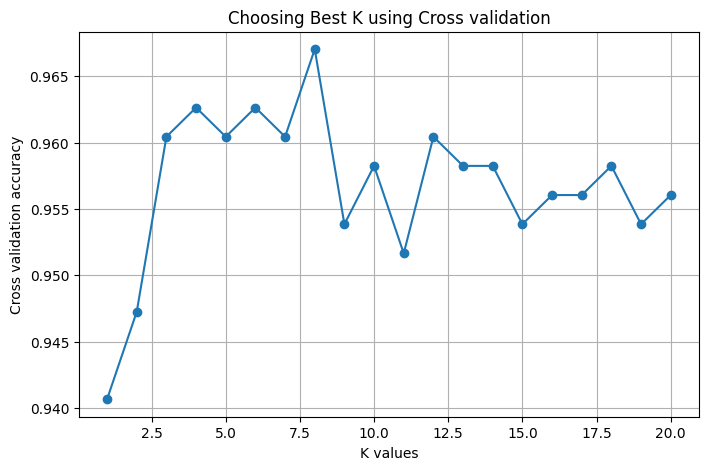

In [14]:
plt.figure(figsize=(8,5))
plt.plot(k_values , cv_score,marker='o')

plt.xlabel("K values")
plt.ylabel("Cross validation accuracy")
plt.title("Choosing Best K using Cross validation")

plt.grid()

plt.show()

In [ ]:
from sklearn.metrics import accuracy_score
best_k = 8

# creates Final KNN model
knn = KNeighborsClassifier(n_neighbors=k)

# train the model 
knn.fit(X_train,y_train)

# predict labels from unseen data
y_pred = knn.predict(X_test)

# comapre prediction with true labels
accuracy = accuracy_score(y_test,y_pred)

print("Final test accuracy: ",accuracy)


Final test accuracy:  0.956140350877193


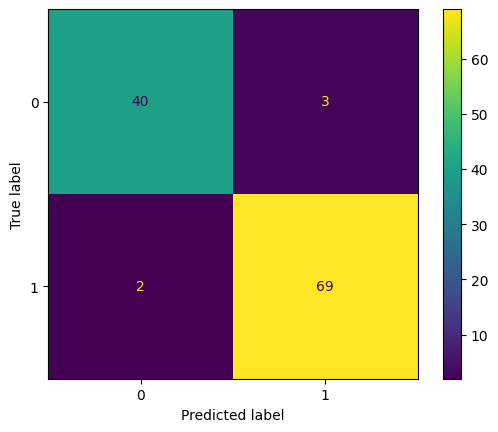

In [16]:
from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay

cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()
